# все стоит на месте

все fr стоит на месте: доли тем, геометрия векторов, покрытие словаря, устойчивость кластеров

мерить нечего?

PS этот ноутбук я оформлял самым последним, потому какие то детали могу упускать(

Импорты

In [2]:
import os, warnings; warnings.filterwarnings("ignore")
while not os.path.isdir("chats"): os.chdir("..")
import json, numpy as np, pandas as pd, seaborn as sns, joblib
sns.set_theme(style="whitegrid", palette="deep", rc={"figure.figsize": (8, 4.5)})

In [64]:
df = pd.read_csv("chats/physics/df.csv", parse_dates=["ts"])
yr_all = dict(zip(df["unit_id"], df["year"]))
meg_all = dict(zip(df["unit_id"], df["mega"]))
df = df[~df["is_bot"]].reset_index(drop=True)
cats = sorted(df["mega"].unique())

In [ ]:
df.iloc[0]

In [5]:
ids = json.load(open("chats/physics/vec/ids_ctx.json"))
row = {u: i for i, u in enumerate(ids)}
B = np.load("chats/physics/vec/dense_ctx.f16.npy").astype(np.float32)
B /= np.linalg.norm(B, axis=1, keepdims=True) + 1e-9 #для устойчивости

len(B)

120127

## доли тем по времени по времени

Посчитаем как меняется доля тем (если считать это как количество сообщений в окне которые принадлежат теме k) от скользящего окна

<Axes: xlabel='кв', ylabel='доля'>

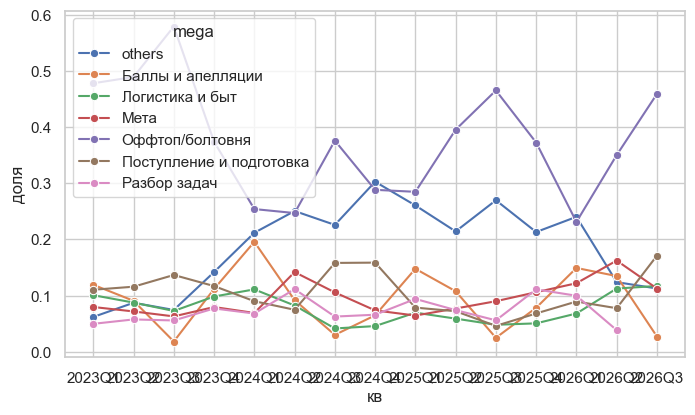

In [95]:
df["кв"] = df["ts"].dt.to_period("Q").astype(str)
t = df.groupby(["кв", "mega"]).size().reset_index(name="n")

t["доля"] = t["n"] / t.groupby("кв")["n"].transform("sum")
sns.lineplot(data=t, x="кв", y="доля", hue="mega", marker="o")

##### все темы в меру своего среднего скачут достаточно сильно
##### но четкого тренда не прослеживается

Посмотрим это в более удобной тепловой карте

<Axes: xlabel='кв', ylabel='mega'>

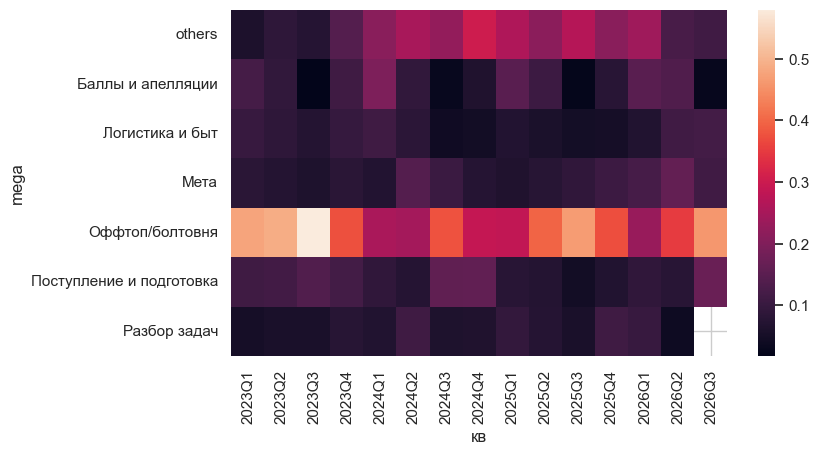

In [5]:
M = t.pivot(index="mega", columns="кв", values="доля")
sns.heatmap(M.loc[cats])

сравним доли тем в 2024 и 2026

<Axes: xlabel='2024', ylabel='2026'>

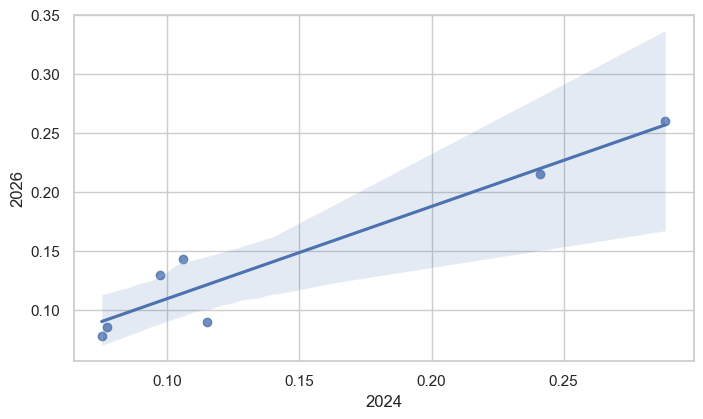

In [21]:
p24 = df[df["year"] == 2024]["mega"].value_counts(normalize=True)
p26 = df[df["year"] == 2026]["mega"].value_counts(normalize=True)

comp = pd.DataFrame({"2024": p24, "2026": p26})
sns.regplot(data=comp, x="2024", y="2026")

<Axes: xlabel='доля', ylabel='mega'>

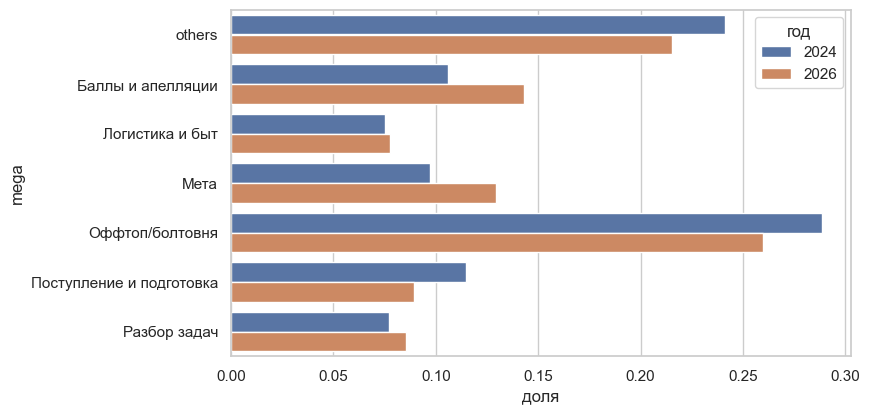

In [22]:
comp2 = comp.rename_axis("mega").reset_index().melt("mega", var_name="год", value_name="доля")
sns.barplot(data=comp2, y="mega", x="доля", hue="год")

In [ ]:
#выглядит похоже очень

## словарь тем не перестает быть актуальным!

в пайплайне центроиды построены на ОДНОМ 3-месячном окне, проверим работает ли этот словарь на ВСЕМ корпусе:

если нет на далеких по времени сообщениях то среднее расстояние до ближайшей темы (кластера) должно расти (темы "уезжают") - как скалярная норма в норм пространстве - сделаем аггр статистику

In [ ]:
df.iloc[0]

In [98]:
m = joblib.load("chats/physics/topics/model.joblib")
m

{'pca': PCA(n_components=50, random_state=0, whiten=True),
 'km': KMeans(n_clusters=50, n_init=10, random_state=0),
 'train_mean': array([ 0.00037027, -0.0033898 , -0.00143221, ..., -0.00234687,
        -0.01448215, -0.0017053 ], dtype=float32),
 'drop_first': False}

In [99]:
W = m["pca"].transform(B - m["train_mean"]) 
d1 = m["km"].transform(W).min(1)     
df["d1"] = [d1[row[u]] for u in df["unit_id"]]


<Axes: xlabel='кв', ylabel='d1'>

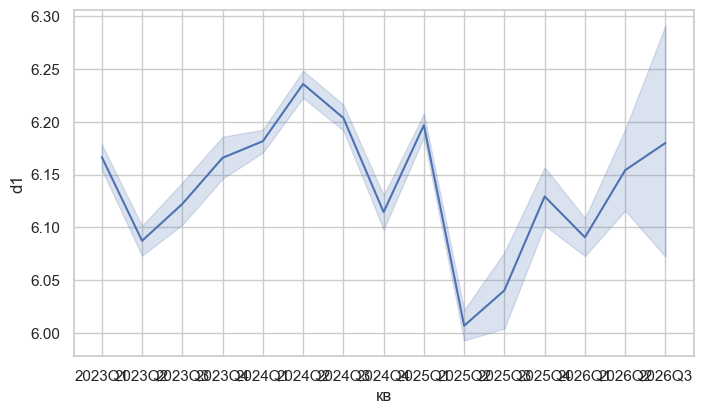

In [97]:
sns.lineplot(data=df, x="кв", y="d1")

In [100]:
#примерно константа на всех 3 годах 
#тогда словарь с одного окна покрывает весь корпус, не перестает быть репрезентативным!!!!!!

## само многообразие фиксировано

не только доли, но и форма облака векторов

сначала косинусы случайных пар по годам

посмотрим на распределения кос сходства случайных пар по разным годам

In [77]:
t = np.array([yr_all[u] for u in ids])
t

array([2023, 2023, 2023, ..., 2026, 2026, 2026])

In [44]:
def pair_cos(year):
    idx = np.where(t == year)[0]
    a = W[np.random.choice(idx, 5000)]
    b = W[np.random.choice(idx, 5000)]
    return (a * b).sum(1) / (np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1))

In [55]:
res = pd.DataFrame({"cos": list(pair_cos(2023)) + list(pair_cos(2025)),
                    "год": ["2023"]*5000 + ["2025"]*5000})
res

,cos,год
0,0.118439,2023
1,0.106869,2023
2,-0.118134,2023
3,0.108094,2023
4,0.088279,2023
...,...,...
9995,0.094490,2025
9996,-0.074636,2025
9997,-0.138132,2025
9998,0.261785,2025


<Axes: xlabel='cos', ylabel='Density'>

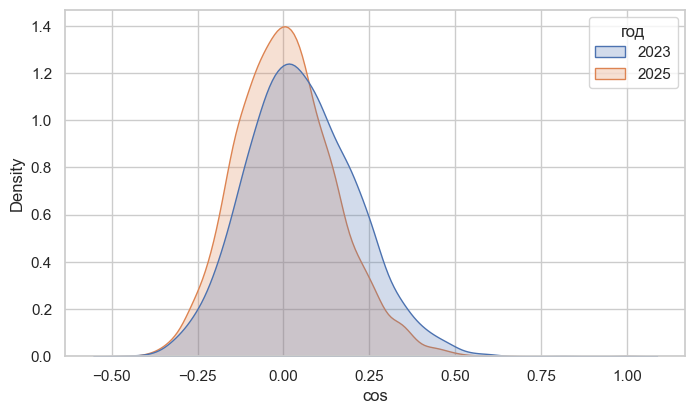

In [56]:
sns.kdeplot(data=res, x="cos", hue="год", fill=True)

<Axes: xlabel='cos', ylabel='Density'>

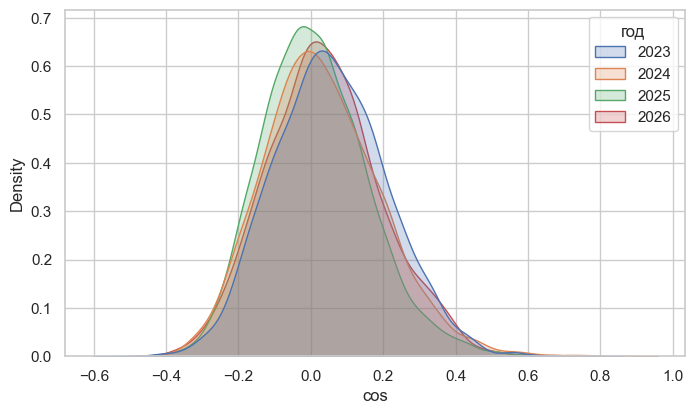

In [58]:
res = pd.DataFrame({"cos": list(pair_cos(2023)) + list(pair_cos(2024)) + list(pair_cos(2025)) + list(pair_cos(2026)),
                    "год": ["2023"]*5000 + ["2024"]*5000 + ["2025"]*5000 + ["2026"]*5000})
sns.kdeplot(data=res, x="cos", hue="год", fill=True)

In [57]:
#практически не отличается распределение
#можно помахать руками что тут все статично

## как центроиды двигаются???

In [ ]:
g = np.array([meg_all[u] for u in ids])
g

array(['Разбор задач', 'Разбор задач', 'Разбор задач', ...,
       'Оффтоп/болтовня', 'Оффтоп/болтовня', 'Оффтоп/болтовня'],
      dtype='<U24')

In [75]:
years = [2023, 2024, 2025, 2026]

rows = []
for c in cats:
    v_all = B[g == c].mean(0)          # центроид темы за ВСЕ годы (эталон)
    v_all /= np.linalg.norm(v_all)
    for y in years:
        v = B[(t == y) & (g == c)].mean(0)
        v /= np.linalg.norm(v)
        rows.append({"тема": c, "год": y, "cos": v @ v_all})
rows = pd.DataFrame(rows)

rows

,тема,год,cos
0,others,2023,NaN
1,others,2024,NaN
2,others,2025,NaN
3,others,2026,NaN
4,Баллы и апелляции,2023,NaN
5,Баллы и апелляции,2024,NaN
6,Баллы и апелляции,2025,NaN
7,Баллы и апелляции,2026,NaN
8,Логистика и быт,2023,NaN
9,Логистика и быт,2024,NaN


array([ True,  True,  True, ...,  True,  True,  True])

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

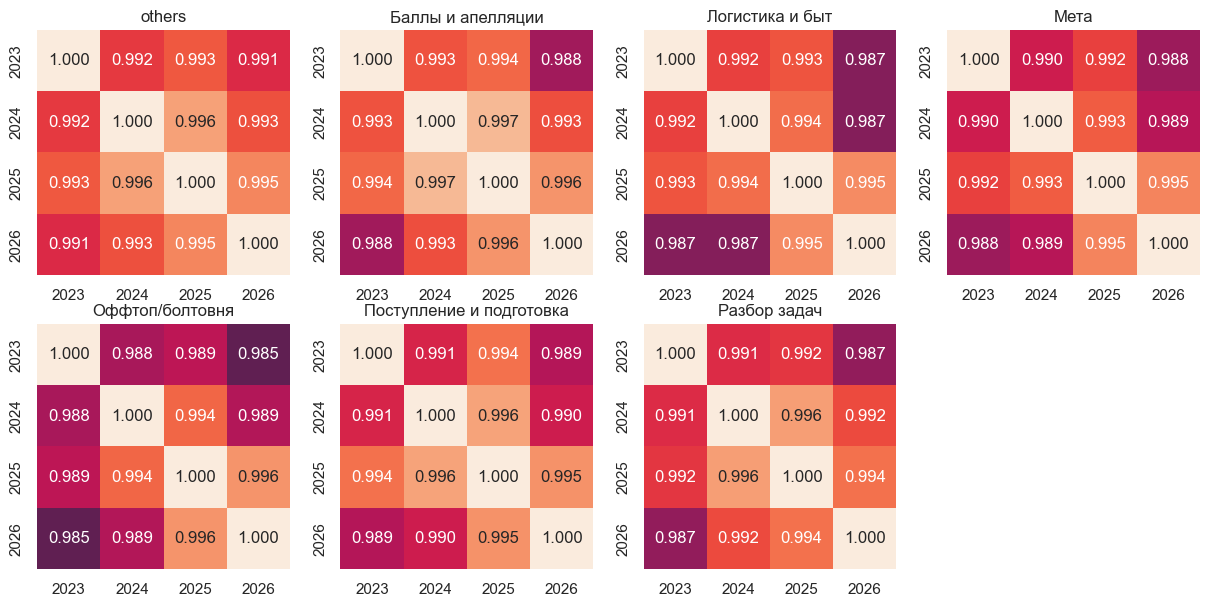

In [86]:
# gemini сделал эти прекрасные графички { 
import matplotlib.pyplot as plt
years = [2023, 2024, 2025, 2026]

def cen(c, y):                            
    v = B[(g == c) & (t == y)].mean(0)
    return v / np.linalg.norm(v)

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for c, ax in zip(cats, axes.flat):
    M = [[cen(c, y1) @ cen(c, y2) for y2 in years] for y1 in years]
    sns.heatmap(M, ax=ax, xticklabels=years, yticklabels=years,
                annot=True, fmt=".3f", vmin=0.98, vmax=1, cbar=False)
    ax.set_title(c)
axes.flat[-1].axis("off")                
#}

In [ ]:
#все ~0.98-0.99 - центры тем стоят на месте

## итоги

все стоит:
1. доли тем не меняются (по годам сильно скореллированы)
2. словарь тем с одного 3-мес окна одинаково покрывает все 3 года
3. геометрия векторов не двигается: тот же конус, центры тем стоят 

то есть аггрегированные статистики неподвижены - многообразия фиксированы

TBH я очень расстроился когда увидел это и подумал что тут нечего делать